0      ADBL
1       API
2      HATH
3    HATHPO
4      AKPL
Name: Symbol, dtype: str

===== Processing ADBL =====
   Close  Decayed_Sentiment
0  255.0                0.0
1  138.0                0.0
2  125.0                0.0
3  122.0                0.0
4  118.0                0.0


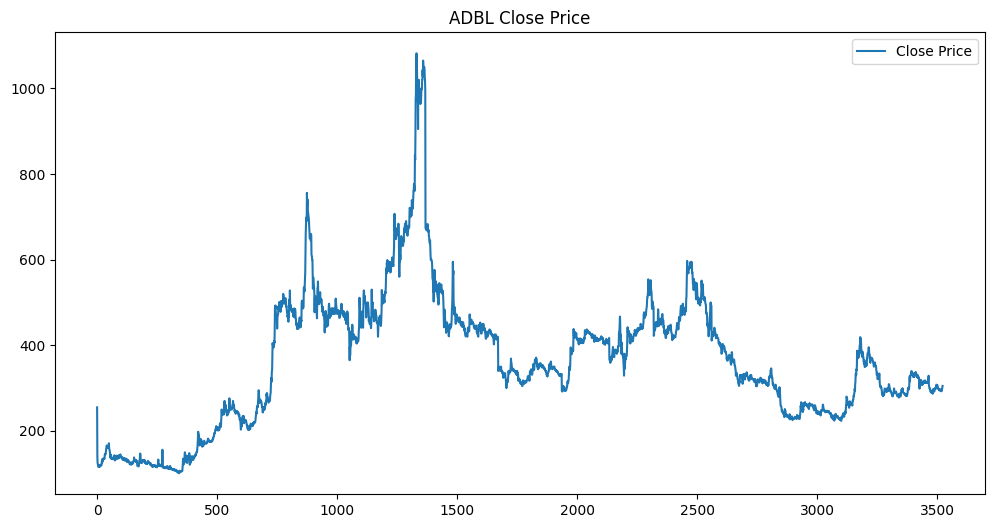

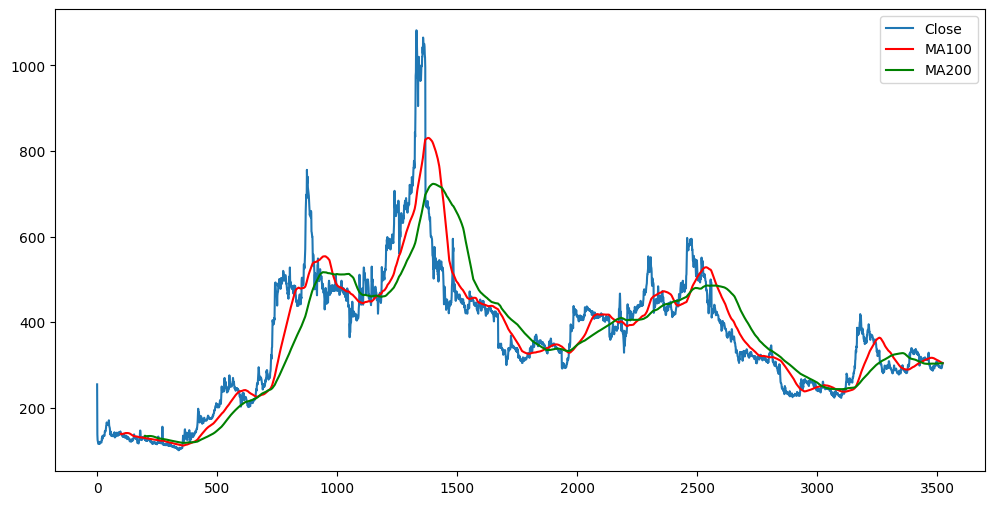

x_train shape: (2366, 100, 2)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - loss: 0.0233 - val_loss: 9.6572e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - loss: 0.0067 - val_loss: 0.0033
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - loss: 0.0056 - val_loss: 0.0012
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 0.0044 - val_loss: 0.0017
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - loss: 0.0040 - val_loss: 8.5148e-04
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - loss: 0.0042 - val_loss: 5.8132e-04
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: 0.0042 - val_loss: 9.6286e-04
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - loss: 0.0036 - val_loss: 5.7893e-04
Epoch 12/50
60/60 ━━━━━━━━━━

Model saved → ../DATA-HTML-STOCK/Models/ADBL_lstm.h5
x_test shape: (1057, 100, 2)
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step

===== Metrics for ADBL =====
MSE  : 737.5476
RMSE : 27.1578
MAE  : 23.2826
R²   : 0.8818
MAPE : 8.0918%
Accuracy (100 - MAPE): 91.9082%


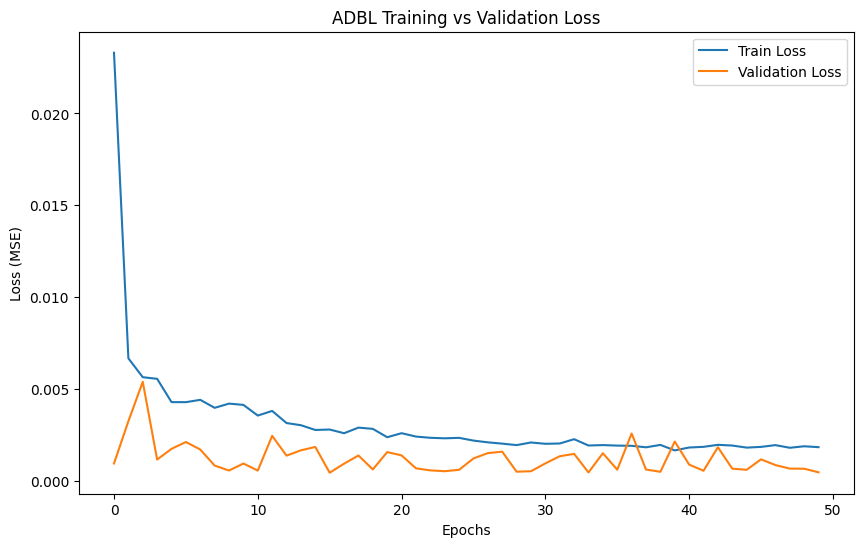

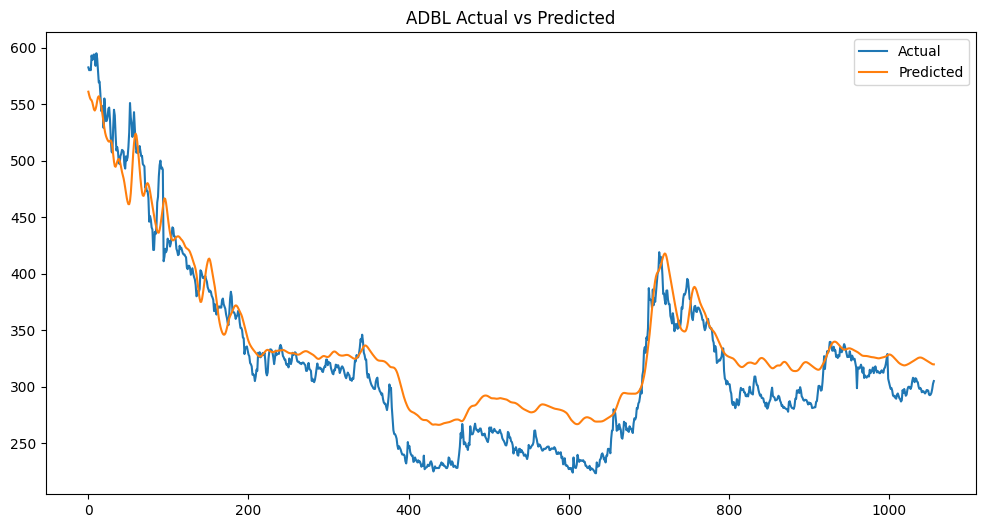

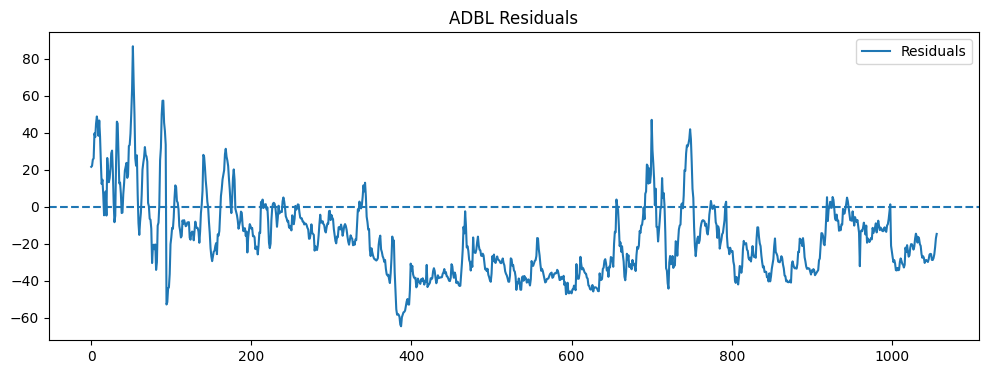

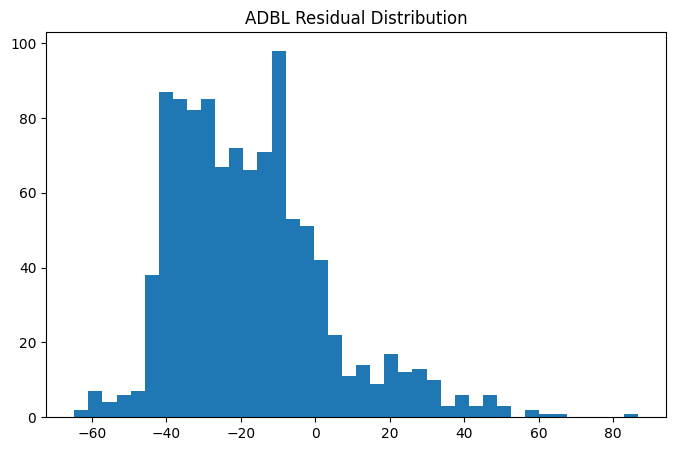

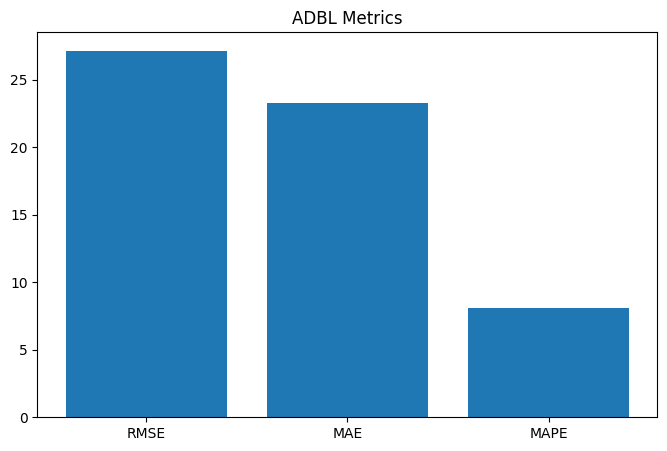

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Tomorrow Price ADBL: 320.08
Current Price ADBL: 305.00


In [3]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Fix Python random
random.seed(42)

# Fix NumPy random
np.random.seed(42)

# Fix TensorFlow random
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS = 100
EPOCHS = 50
# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
print(symbols.head())
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
# needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]
needCompareModel = ["BARUN"]
all_metrics = []
for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"

    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD DATA =================
    df = pd.read_csv(stock_path)
    df = df[['Close','Decayed_Sentiment']].dropna()
    df = df.reset_index(drop=True)
    df = df.iloc[::-1].reset_index(drop=True)
    print(df.head())

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close Price')
    plt.title(f"{symbol} Close Price")
    plt.legend()
    plt.show()

    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.legend()
    plt.show()

    # ================= TRAIN TEST SPLIT =================
    data = df[['Close','Decayed_Sentiment']]

    train_size = int(len(data) * 0.7)
    data_train = data[:train_size]
    data_test  = data[train_size:]

    # ================= SCALING (FIT ONLY ON TRAIN) =================
    scaler = MinMaxScaler(feature_range=(0,1))
    train_scaled = scaler.fit_transform(data_train)

    # ================= CREATE TRAIN SEQUENCES =================
    x_train, y_train = [], []

    for i in range(TIME_STEPS, len(train_scaled)):
        x_train.append(train_scaled[i-TIME_STEPS:i])
        y_train.append(train_scaled[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)

    print("x_train shape:", x_train.shape)

    # ================= MODEL =================
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(TIME_STEPS,2)))
    model.add(Dropout(0.2))

    model.add(LSTM(60, activation='relu', return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.4))

    model.add(LSTM(120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split=0.2, verbose=1)

    # ================= SAVE MODEL =================
    MODEL_DIR = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.h5")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    past_100 = data_train.tail(TIME_STEPS)
    final_df = pd.concat([past_100, data_test], ignore_index=True)

    # IMPORTANT: NO FIT HERE
    input_scaled = scaler.transform(final_df)

    x_test, y_test = [], []

    for i in range(TIME_STEPS, len(input_scaled)):
        x_test.append(input_scaled[i-TIME_STEPS:i])
        y_test.append(input_scaled[i, 0])

    x_test, y_test = np.array(x_test), np.array(y_test)

    print("x_test shape:", x_test.shape)

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE SCALING (CORRECT WAY) =================
    # y_pred = scaler.inverse_transform(y_pred)
    # y_test = scaler.inverse_transform(y_test.reshape(-1,1))

    # ================= INVERSE SCALING FOR MULTI-FEATURE SCALER =================
    # For predicted values
    y_pred_close = y_pred.copy()  # shape (n,1)
    y_pred_full = np.zeros((y_pred_close.shape[0], 2))  # 2 = number of features used in scaler
    y_pred_full[:,0] = y_pred_close[:,0]  # first column = Close
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:,0]  # get only Close

    # For test values
    y_test_close = y_test.reshape(-1,1)
    y_test_full = np.zeros((y_test_close.shape[0], 2))
    y_test_full[:,0] = y_test_close[:,0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:,0]

    y_pred_flat = y_pred_inv
    y_test_flat = y_test_inv

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_flat, y_pred_flat)
    r2   = r2_score(y_test_flat, y_pred_flat)

    # SAFE MAPE
    mask = y_test_flat != 0
    mape = np.mean(np.abs((y_test_flat[mask] - y_pred_flat[mask]) / y_test_flat[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")


    FIG_DIR   = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    

    # ================= PLOT 1: Train VS Validation Loss =================
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_train_vs_test_loss.png"))
    plt.show()
    
    # ================= PLOT 1: ACTUAL VS PRED =================
    plt.figure(figsize=(12,6))
    plt.plot(y_test_flat, label='Actual')
    plt.plot(y_pred_flat, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Actual vs Predicted")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # ================= PLOT 2: RESIDUAL =================
    residuals = y_test_flat - y_pred_flat

    plt.figure(figsize=(12,4))
    plt.plot(residuals, label='Residuals')
    plt.axhline(0, linestyle='--')
    plt.legend()
    plt.title(f"{symbol} Residuals")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot 3: Residual Histogram
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=40)
    plt.title(f"{symbol} Residual Distribution")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()
    plt.close()

    # Plot 4: Metrics Bar
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    plt.figure(figsize=(8,5))
    plt.bar(metrics_plot.keys(), metrics_plot.values())
    plt.title(f"{symbol} Metrics")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()
    plt.close()

    # ================= PLOT 4: METRICS =================
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    # ================= SAVE METRICS =================
    all_metrics.append({
        "Symbol": symbol,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

    # ================= SAVE ALL METRICS CSV =================
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW PREDICTION =================
    last_100_days = data.tail(TIME_STEPS)  
    last_scaled = scaler.transform(last_100_days)
    X_input = np.array([last_scaled])
    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy = np.zeros((1, 2))
    dummy[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    current_price = data['Close'].iloc[-1]
    print(f"Current Price {symbol}: {current_price:.2f}")



0      ADBL
1       API
2      HATH
3    HATHPO
4      AKPL
Name: Symbol, dtype: str

===== Processing NTC =====
   Close  Decayed_Sentiment
0  446.0                0.0
1  462.0                0.0
2  460.0                0.0
3  458.0                0.0
4  450.0                0.0


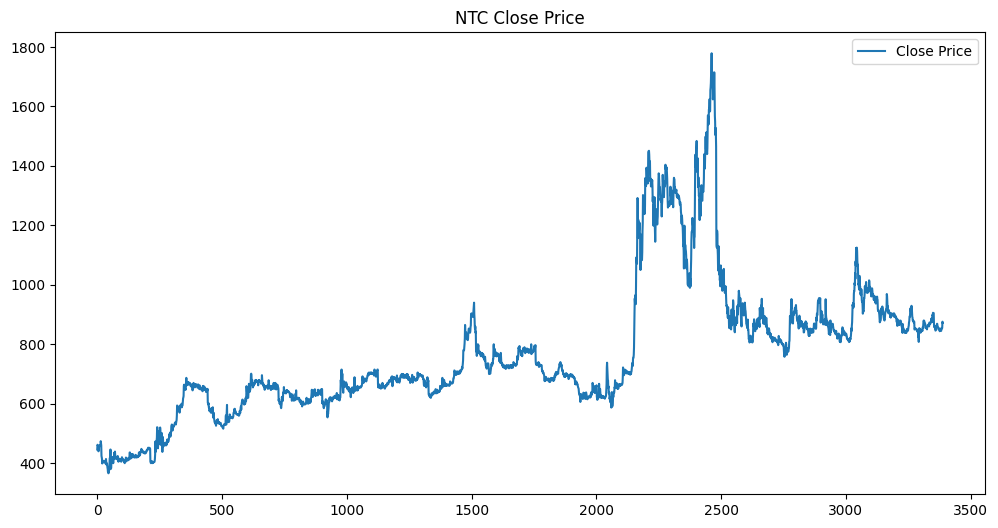

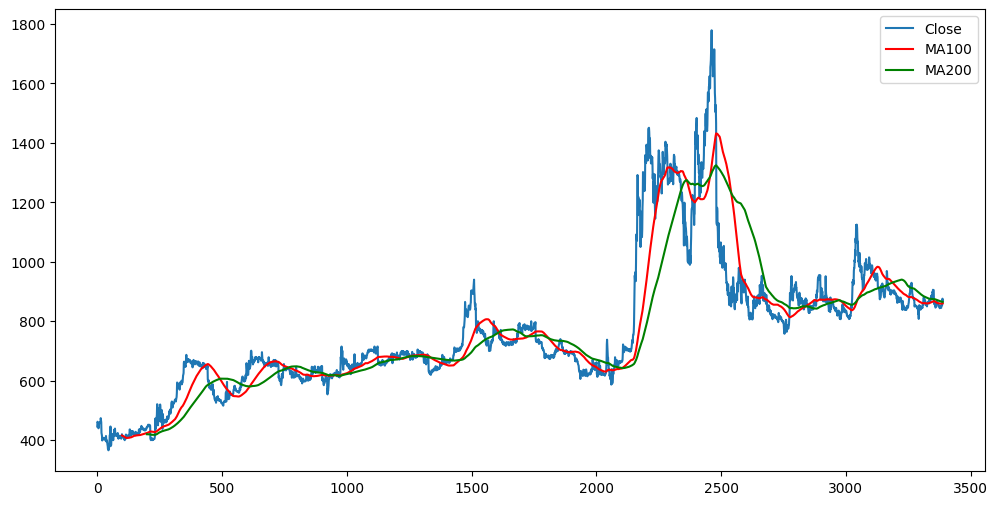

x_train shape: (2272, 100, 2)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - loss: 0.0108 - val_loss: 0.0122
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.0030 - val_loss: 0.0223
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - loss: 0.0022 - val_loss: 0.0130
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0023 - val_loss: 0.0297
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - loss: 0.0019 - val_loss: 0.0156
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - loss: 0.0018 - val_loss: 0.0213
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - loss: 0.0018 - val_loss: 0.0141
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - loss: 0.0015 - val_loss: 0.0169
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 0.0015 - val_loss: 0.0106
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 0.0014 - val_loss: 0.0204
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 0.0012 - val_loss: 0.0178
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms

Model saved → ../DATA-HTML-STOCK/Models/NTC_lstm.h5
x_test shape: (1017, 100, 2)
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step

===== Metrics for NTC =====
MSE  : 11315.0423
RMSE : 106.3722
MAE  : 55.5868
R²   : 0.6568
MAPE : 5.6615%
Accuracy (100 - MAPE): 94.3385%


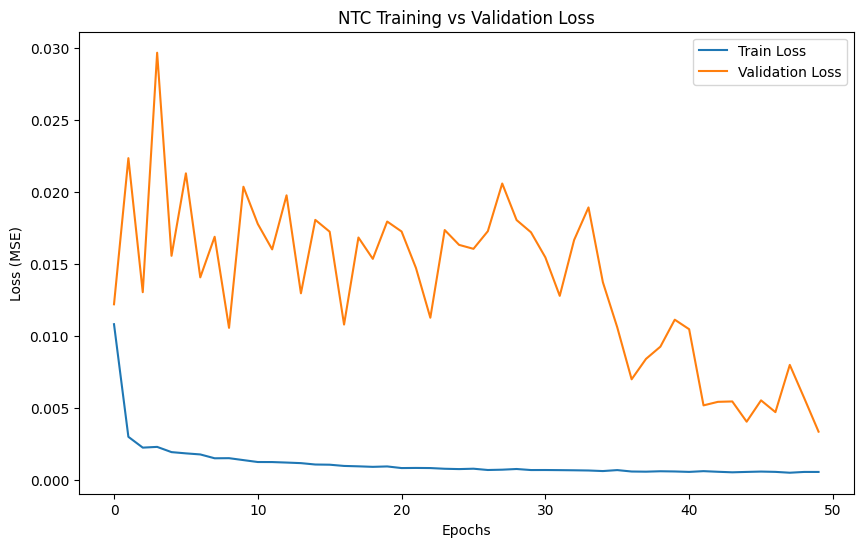

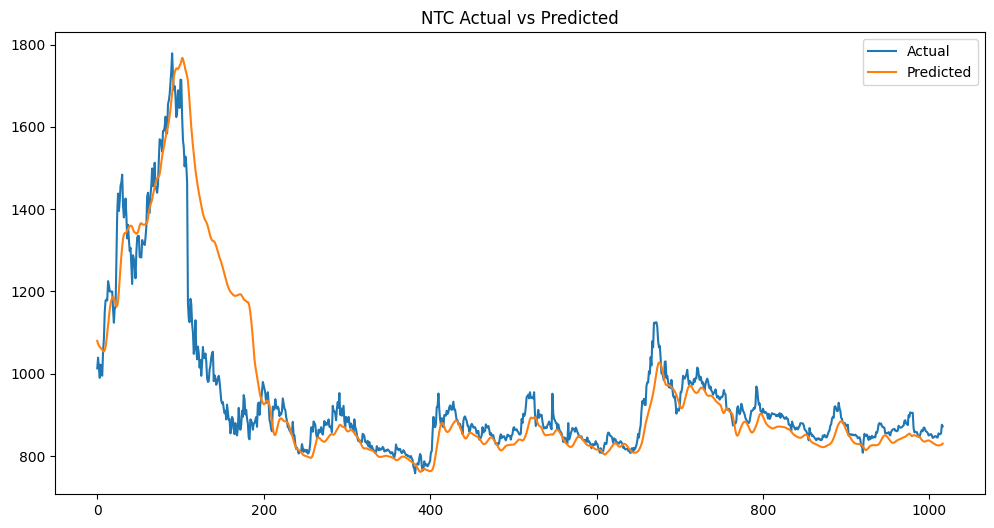

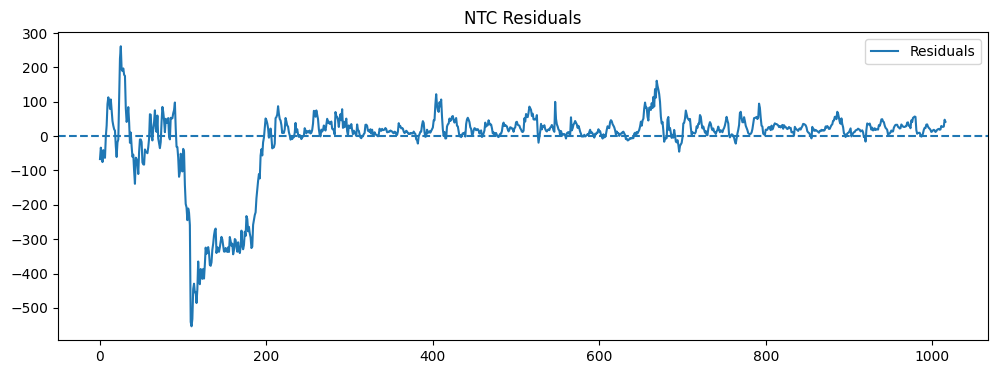

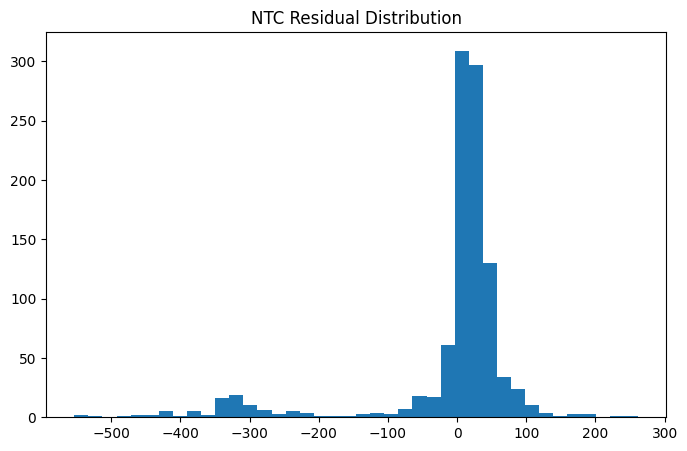

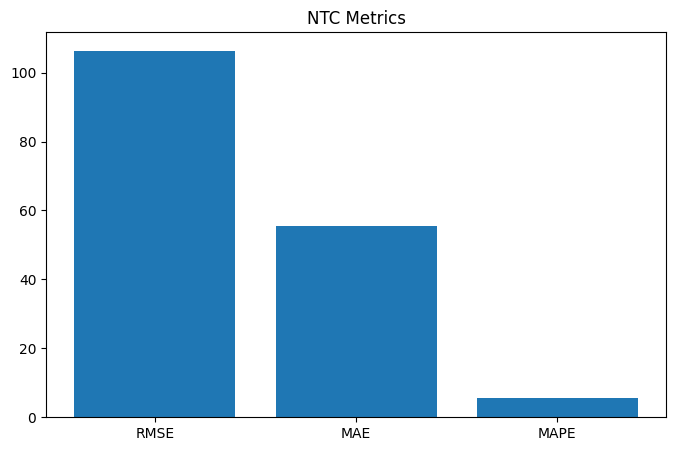

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Tomorrow Price NTC: 832.88
Current Price NTC: 872.00
Latest date: 2026-03-03
  Backend error: HTTPConnectionPool(host='192.168.254.13', port=80): Max retries exceeded with url: /predicted_price (Caused by ConnectTimeoutError(<HTTPConnection(host='192.168.254.13', port=80) at 0x7950bbfa3aa0>, 'Connection to 192.168.254.13 timed out. (connect timeout=None)'))


In [8]:
import json
import requests
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Fix Python random
random.seed(42)

# Fix NumPy random
np.random.seed(42)

# Fix TensorFlow random
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS = 100
EPOCHS = 50
# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
print(symbols.head())
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
# needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]
needCompareModel = ["NTC"]
all_metrics = []
for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"

    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD DATA =================
    df = pd.read_csv(stock_path)
    df = df[['Close','Decayed_Sentiment']].dropna()
    df = df.reset_index(drop=True)
    df = df.iloc[::-1].reset_index(drop=True)
    print(df.head())

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close Price')
    plt.title(f"{symbol} Close Price")
    plt.legend()
    plt.show()

    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.legend()
    plt.show()

    # ================= TRAIN TEST SPLIT =================
    data = df[['Close','Decayed_Sentiment']]

    train_size = int(len(data) * 0.7)
    data_train = data[:train_size]
    data_test  = data[train_size:]

    # ================= SCALING (FIT ONLY ON TRAIN) =================
    scaler = MinMaxScaler(feature_range=(0,1))
    train_scaled = scaler.fit_transform(data_train)

    # ================= CREATE TRAIN SEQUENCES =================
    x_train, y_train = [], []

    for i in range(TIME_STEPS, len(train_scaled)):
        x_train.append(train_scaled[i-TIME_STEPS:i])
        y_train.append(train_scaled[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)

    print("x_train shape:", x_train.shape)

    # ================= MODEL =================
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(TIME_STEPS,2)))
    model.add(Dropout(0.2))

    model.add(LSTM(60, activation='relu', return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.4))

    model.add(LSTM(120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split=0.2, verbose=1)

    # ================= SAVE MODEL =================
    MODEL_DIR = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.h5")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    past_100 = data_train.tail(TIME_STEPS)
    final_df = pd.concat([past_100, data_test], ignore_index=True)

    # IMPORTANT: NO FIT HERE
    input_scaled = scaler.transform(final_df)

    x_test, y_test = [], []

    for i in range(TIME_STEPS, len(input_scaled)):
        x_test.append(input_scaled[i-TIME_STEPS:i])
        y_test.append(input_scaled[i, 0])

    x_test, y_test = np.array(x_test), np.array(y_test)

    print("x_test shape:", x_test.shape)

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE SCALING (CORRECT WAY) =================
    # y_pred = scaler.inverse_transform(y_pred)
    # y_test = scaler.inverse_transform(y_test.reshape(-1,1))

    # ================= INVERSE SCALING FOR MULTI-FEATURE SCALER =================
    # For predicted values
    y_pred_close = y_pred.copy()  # shape (n,1)
    y_pred_full = np.zeros((y_pred_close.shape[0], 2))  # 2 = number of features used in scaler
    y_pred_full[:,0] = y_pred_close[:,0]  # first column = Close
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:,0]  # get only Close

    # For test values
    y_test_close = y_test.reshape(-1,1)
    y_test_full = np.zeros((y_test_close.shape[0], 2))
    y_test_full[:,0] = y_test_close[:,0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:,0]

    y_pred_flat = y_pred_inv
    y_test_flat = y_test_inv

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_flat, y_pred_flat)
    r2   = r2_score(y_test_flat, y_pred_flat)

    # SAFE MAPE
    mask = y_test_flat != 0
    mape = np.mean(np.abs((y_test_flat[mask] - y_pred_flat[mask]) / y_test_flat[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")


    FIG_DIR   = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    

    # ================= PLOT 1: Train VS Validation Loss =================
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_train_vs_valid_loss.png"))
    plt.show()
    
    # ================= PLOT 1: ACTUAL VS PRED =================
    plt.figure(figsize=(12,6))
    plt.plot(y_test_flat, label='Actual')
    plt.plot(y_pred_flat, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Actual vs Predicted")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # ================= PLOT 2: RESIDUAL =================
    residuals = y_test_flat - y_pred_flat

    plt.figure(figsize=(12,4))
    plt.plot(residuals, label='Residuals')
    plt.axhline(0, linestyle='--')
    plt.legend()
    plt.title(f"{symbol} Residuals")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot 3: Residual Histogram
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=40)
    plt.title(f"{symbol} Residual Distribution")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()
    plt.close()

    # Plot 4: Metrics Bar
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    plt.figure(figsize=(8,5))
    plt.bar(metrics_plot.keys(), metrics_plot.values())
    plt.title(f"{symbol} Metrics")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()
    plt.close()

    # ================= PLOT 4: METRICS =================
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    # ================= SAVE METRICS =================
    all_metrics.append({
        "Symbol": symbol,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

    # ================= SAVE ALL METRICS CSV =================
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW PREDICTION =================
    last_100_days = data.tail(TIME_STEPS)  
    last_scaled = scaler.transform(last_100_days)
    X_input = np.array([last_scaled])
    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy = np.zeros((1, 2))
    dummy[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    current_price = data['Close'].iloc[-1]
    print(f"Current Price {symbol}: {current_price:.2f}")

    df_date = pd.read_csv(stock_path)
    df_date = df_date[['Date_Stock']].dropna()
    df_date = df_date.reset_index(drop=True)
    latest_date = df_date.head(1)['Date_Stock'].values[0]
    print("Latest date:", latest_date)
    
    try:
        requests.post('http://192.168.254.13/predicted_price',json={"predicted_price": float(tomorrow_price), "stock": symbol, "date": latest_date, "current_price": float(current_price)})
        print("  Sent to backend.")
    except Exception as e:
        print(f"  Backend error: {e}")



0      ADBL
1       API
2      HATH
3    HATHPO
4      AKPL
Name: Symbol, dtype: str

===== Processing CHCL =====
   Close  Decayed_Sentiment
0  281.0                0.0
1  336.0                0.0
2  352.0                0.0
3  369.0                0.0
4  387.0                0.0


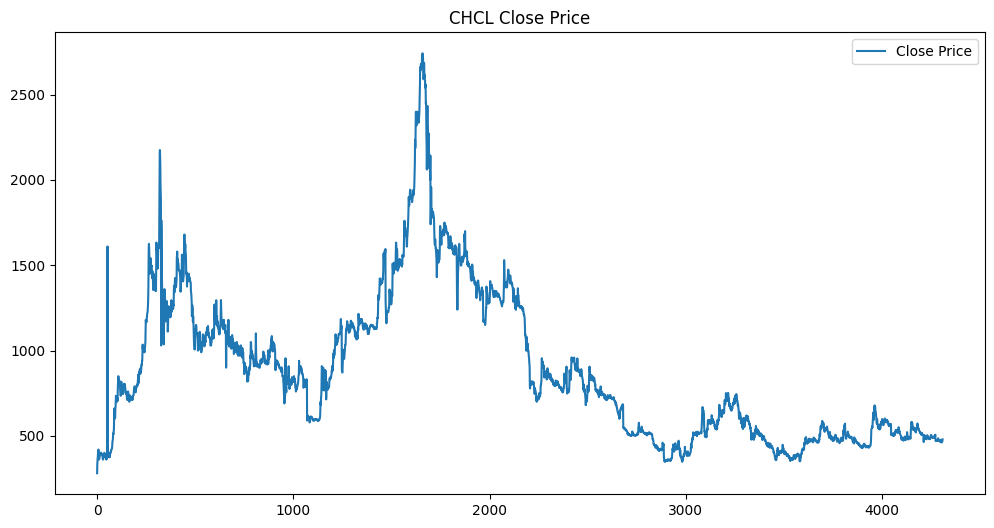

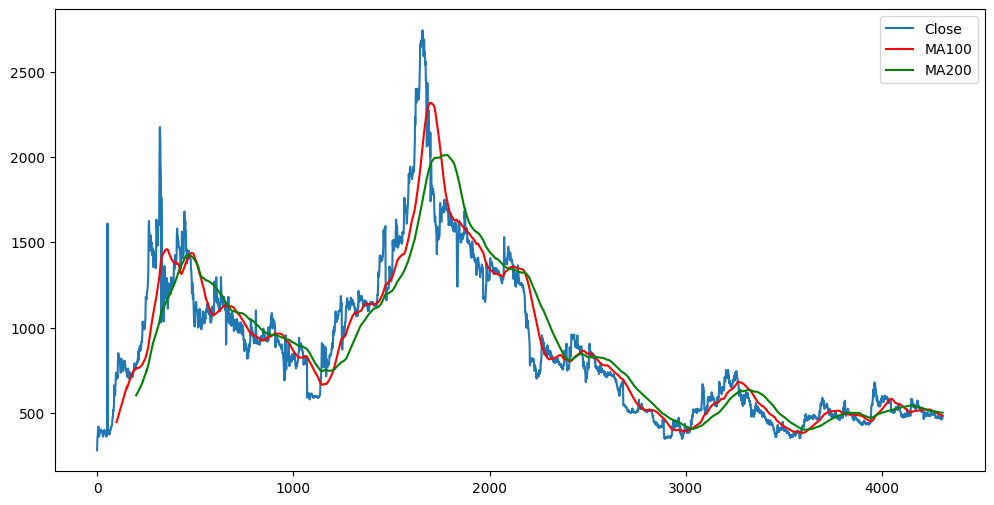

x_train shape: (2916, 100, 2)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - loss: 0.0221 - val_loss: 0.0056
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - loss: 0.0063 - val_loss: 0.0043
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - loss: 0.0063 - val_loss: 0.0042
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - loss: 0.0058 - val_loss: 0.0048
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - loss: 0.0045 - val_loss: 0.0077
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - loss: 0.0047 - val_loss: 0.0027
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - loss: 0.0042 - val_loss: 0.0062
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - loss: 0.0034 - val_loss: 0.0027
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 13

Model saved → ../DATA-HTML-STOCK/Models/CHCL_lstm.h5
x_test shape: (1293, 100, 2)
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step

===== Metrics for CHCL =====
MSE  : 4722.9788
RMSE : 68.7239
MAE  : 59.3543
R²   : 0.2542
MAPE : 12.6762%
Accuracy (100 - MAPE): 87.3238%


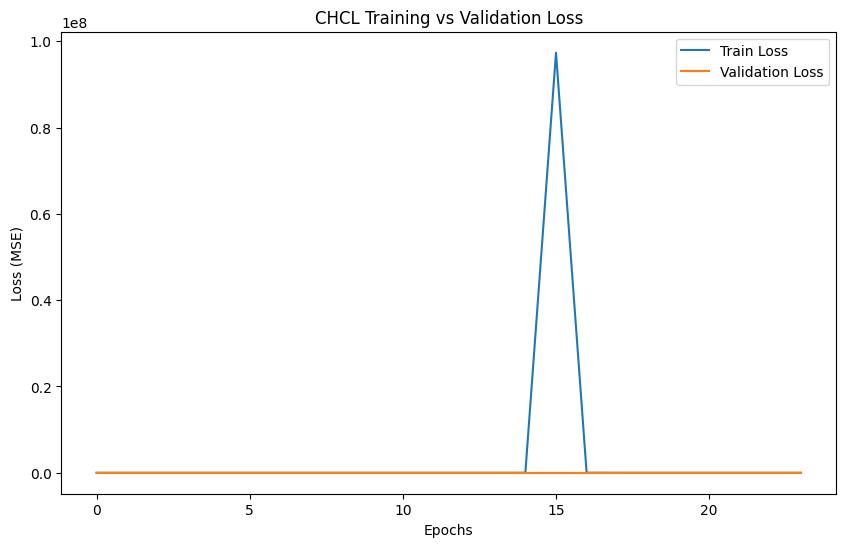

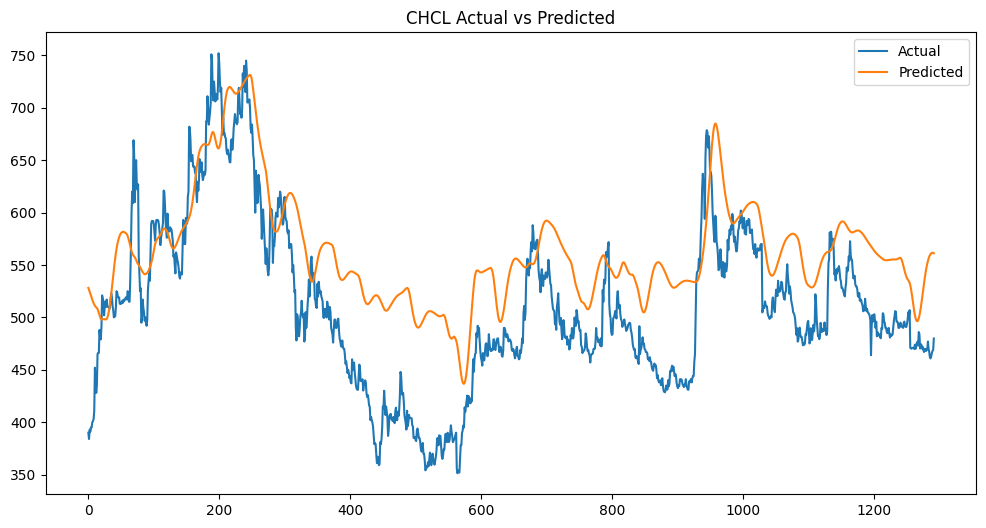

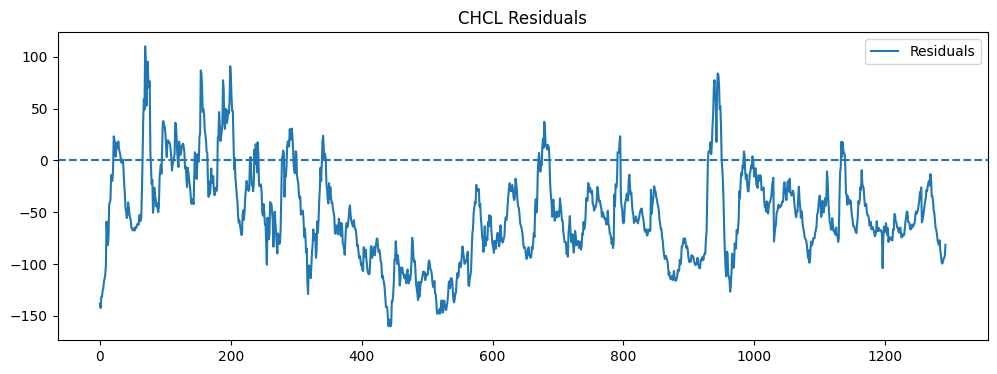

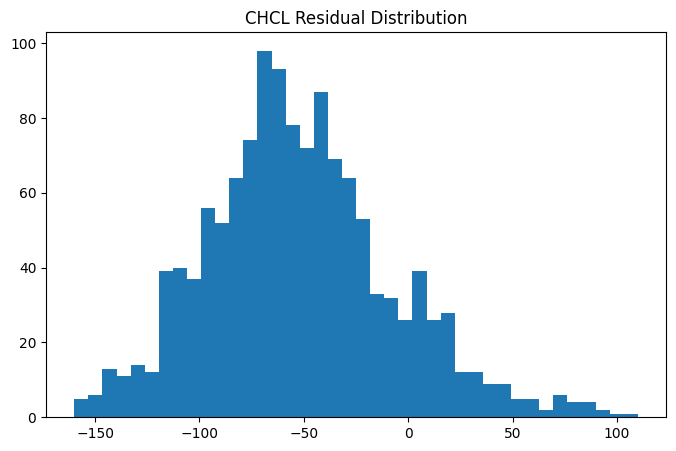

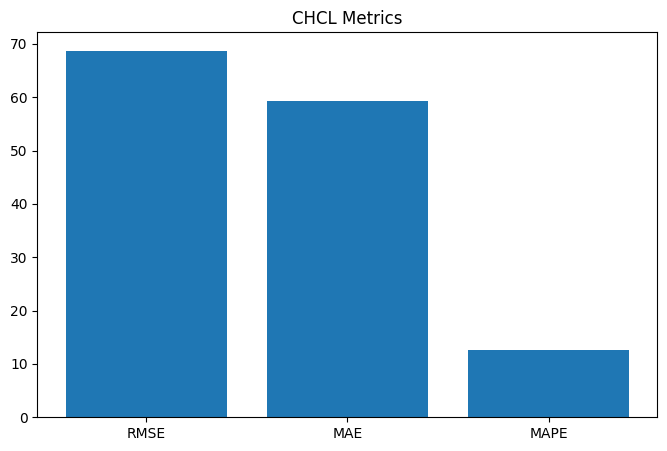

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Tomorrow Price CHCL: 560.68
Current Price CHCL: 479.90
Latest date: 2026-03-03
  Backend error: HTTPConnectionPool(host='192.168.254.13', port=80): Max retries exceeded with url: /predicted_price (Caused by ConnectTimeoutError(<HTTPConnection(host='192.168.254.13', port=80) at 0x794fbf51e570>, 'Connection to 192.168.254.13 timed out. (connect timeout=None)'))


In [11]:
import json
import requests
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Fix Python random
random.seed(42)

# Fix NumPy random
np.random.seed(42)

# Fix TensorFlow random
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS = 100
EPOCHS = 50
# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
print(symbols.head())
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
# needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]
needCompareModel = ["CHCL"]
all_metrics = []
for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"

    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD DATA =================
    df = pd.read_csv(stock_path)
    df = df[['Close','Decayed_Sentiment']].dropna()
    df = df.reset_index(drop=True)
    df = df.iloc[::-1].reset_index(drop=True)
    print(df.head())

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close Price')
    plt.title(f"{symbol} Close Price")
    plt.legend()
    plt.show()

    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.legend()
    plt.show()

    # ================= TRAIN TEST SPLIT =================
    data = df[['Close','Decayed_Sentiment']]

    train_size = int(len(data) * 0.7)
    data_train = data[:train_size]
    data_test  = data[train_size:]

    # ================= SCALING (FIT ONLY ON TRAIN) =================
    scaler = MinMaxScaler(feature_range=(0,1))
    train_scaled = scaler.fit_transform(data_train)

    # ================= CREATE TRAIN SEQUENCES =================
    x_train, y_train = [], []

    for i in range(TIME_STEPS, len(train_scaled)):
        x_train.append(train_scaled[i-TIME_STEPS:i])
        y_train.append(train_scaled[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)

    print("x_train shape:", x_train.shape)

    early_stop = EarlyStopping(
        monitor='val_loss',     
        patience=15,            
        restore_best_weights=True  
    )

    # ================= MODEL =================
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(TIME_STEPS,2)))
    model.add(Dropout(0.2))

    model.add(LSTM(60, activation='relu', return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.4))

    model.add(LSTM(120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split=0.2, verbose=1, callbacks=[early_stop])

    # ================= SAVE MODEL =================
    MODEL_DIR = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.h5")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    past_100 = data_train.tail(TIME_STEPS)
    final_df = pd.concat([past_100, data_test], ignore_index=True)

    # IMPORTANT: NO FIT HERE
    input_scaled = scaler.transform(final_df)

    x_test, y_test = [], []

    for i in range(TIME_STEPS, len(input_scaled)):
        x_test.append(input_scaled[i-TIME_STEPS:i])
        y_test.append(input_scaled[i, 0])

    x_test, y_test = np.array(x_test), np.array(y_test)

    print("x_test shape:", x_test.shape)

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE SCALING (CORRECT WAY) =================
    # y_pred = scaler.inverse_transform(y_pred)
    # y_test = scaler.inverse_transform(y_test.reshape(-1,1))

    # ================= INVERSE SCALING FOR MULTI-FEATURE SCALER =================
    # For predicted values
    y_pred_close = y_pred.copy()  # shape (n,1)
    y_pred_full = np.zeros((y_pred_close.shape[0], 2))  # 2 = number of features used in scaler
    y_pred_full[:,0] = y_pred_close[:,0]  # first column = Close
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:,0]  # get only Close

    # For test values
    y_test_close = y_test.reshape(-1,1)
    y_test_full = np.zeros((y_test_close.shape[0], 2))
    y_test_full[:,0] = y_test_close[:,0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:,0]

    y_pred_flat = y_pred_inv
    y_test_flat = y_test_inv

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_flat, y_pred_flat)
    r2   = r2_score(y_test_flat, y_pred_flat)

    # SAFE MAPE
    mask = y_test_flat != 0
    mape = np.mean(np.abs((y_test_flat[mask] - y_pred_flat[mask]) / y_test_flat[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")


    FIG_DIR   = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    

    # ================= PLOT 1: Train VS Validation Loss =================
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_train_vs_valid_loss.png"))
    plt.show()
    
    # ================= PLOT 1: ACTUAL VS PRED =================
    plt.figure(figsize=(12,6))
    plt.plot(y_test_flat, label='Actual')
    plt.plot(y_pred_flat, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Actual vs Predicted")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # ================= PLOT 2: RESIDUAL =================
    residuals = y_test_flat - y_pred_flat

    plt.figure(figsize=(12,4))
    plt.plot(residuals, label='Residuals')
    plt.axhline(0, linestyle='--')
    plt.legend()
    plt.title(f"{symbol} Residuals")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot 3: Residual Histogram
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=40)
    plt.title(f"{symbol} Residual Distribution")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()
    plt.close()

    # Plot 4: Metrics Bar
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    plt.figure(figsize=(8,5))
    plt.bar(metrics_plot.keys(), metrics_plot.values())
    plt.title(f"{symbol} Metrics")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()
    plt.close()

    # ================= PLOT 4: METRICS =================
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    # ================= SAVE METRICS =================
    all_metrics.append({
        "Symbol": symbol,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

    # ================= SAVE ALL METRICS CSV =================
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW PREDICTION =================
    last_100_days = data.tail(TIME_STEPS)  
    last_scaled = scaler.transform(last_100_days)
    X_input = np.array([last_scaled])
    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy = np.zeros((1, 2))
    dummy[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    current_price = data['Close'].iloc[-1]
    print(f"Current Price {symbol}: {current_price:.2f}")

    df_date = pd.read_csv(stock_path)
    df_date = df_date[['Date_Stock']].dropna()
    df_date = df_date.reset_index(drop=True)
    latest_date = df_date.head(1)['Date_Stock'].values[0]
    print("Latest date:", latest_date)
    
    try:
        requests.post('http://192.168.254.13/predicted_price',json={"predicted_price": float(tomorrow_price), "stock": symbol, "date": latest_date, "current_price": float(current_price)})
        print("  Sent to backend.")
    except Exception as e:
        print(f"  Backend error: {e}")




===== Processing CHCL =====
Total rows after feature engineering: 4308
             Close   pct_change  Decayed_Sentiment
count  4308.000000  4308.000000        4308.000000
mean    884.727314     0.001085           0.040066
std     440.175557     0.058573           0.168071
min     336.000000    -0.763354          -0.913338
25%     511.000000    -0.010000           0.000000
50%     789.000000     0.000000           0.000000
75%    1150.000000     0.008737           0.000000
max    2742.000000     3.304813           1.394303


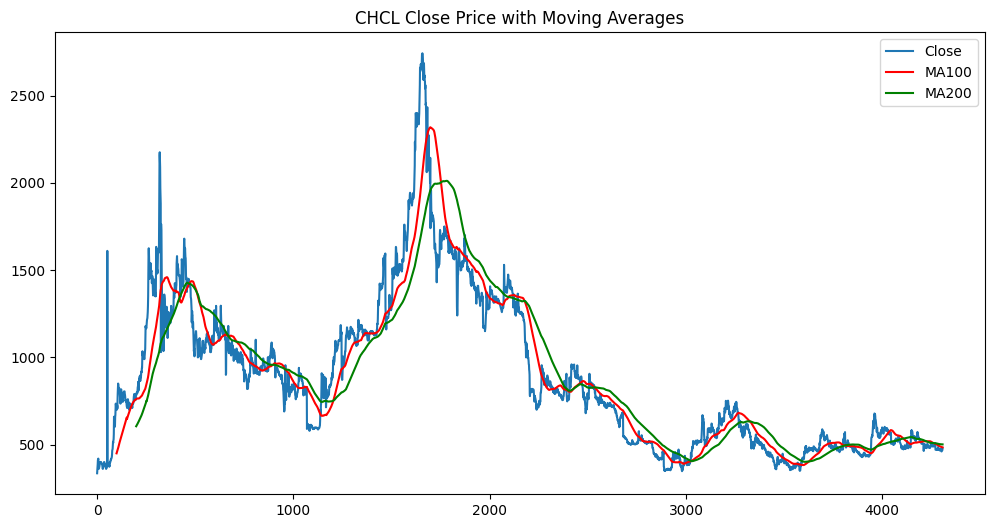

Train: 3015  Val: 431  Test: 862
Train Close range: 336.0 – 2742.0
Val   Close range: 384.0   – 752.0
Test  Close range: 351.3  – 678.6
x_train: (2915, 100, 3)  x_val: (431, 100, 3)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,185 (379.63 KB)

 Trainable params: 97,185 (379.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0112 - val_loss: 6.7888e-04 - learning_rate: 0.0010
Epoch 2/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0032 - val_loss: 4.7820e-04 - learning_rate: 0.0010
Epoch 3/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0024 - val_loss: 5.6752e-04 - learning_rate: 0.0010
Epoch 4/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0022 - val_loss: 3.2537e-04 - learning_rate: 0.0010
Epoch 5/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0018 - val_loss: 2.2024e-04 - learning_rate: 0.0010
Epoch 6/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0017 - val_loss: 5.1920e-04 - learning_rate: 0.0010
Epoch 7/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0016 - val_loss: 1.4693e-04 - learning_rate: 0.0010
Epoch 8/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0014 - val_loss: 1.3884e-04 - learning_rate: 0.0010
Epoch 9/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0013 - val_loss: 8.4736

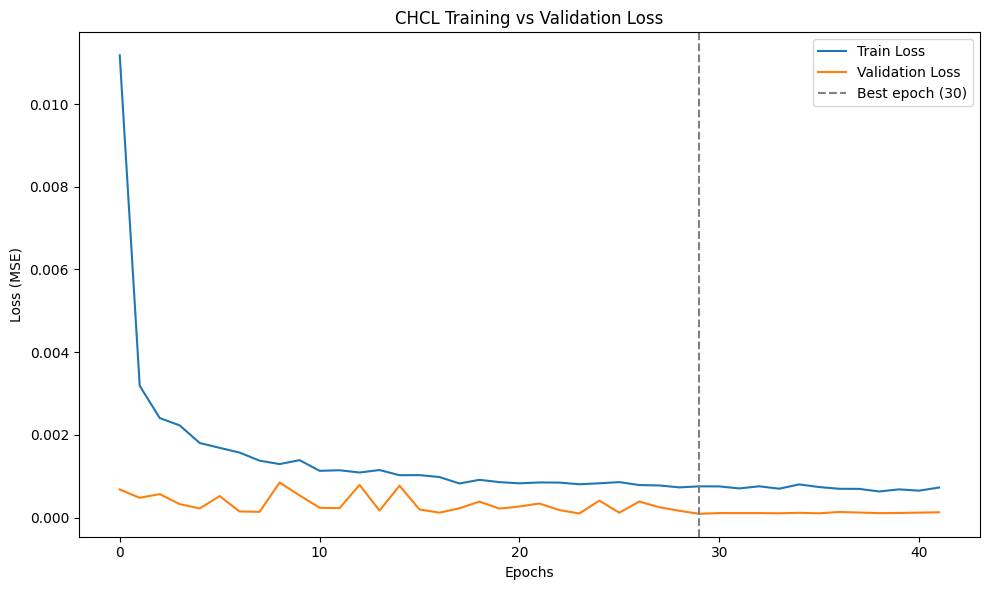

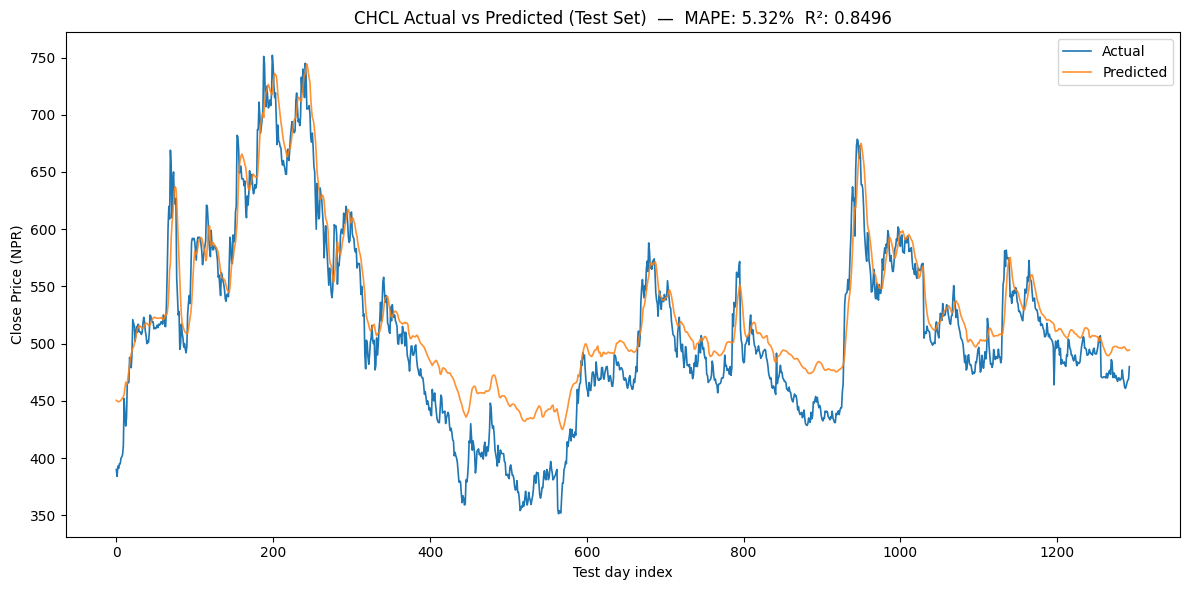

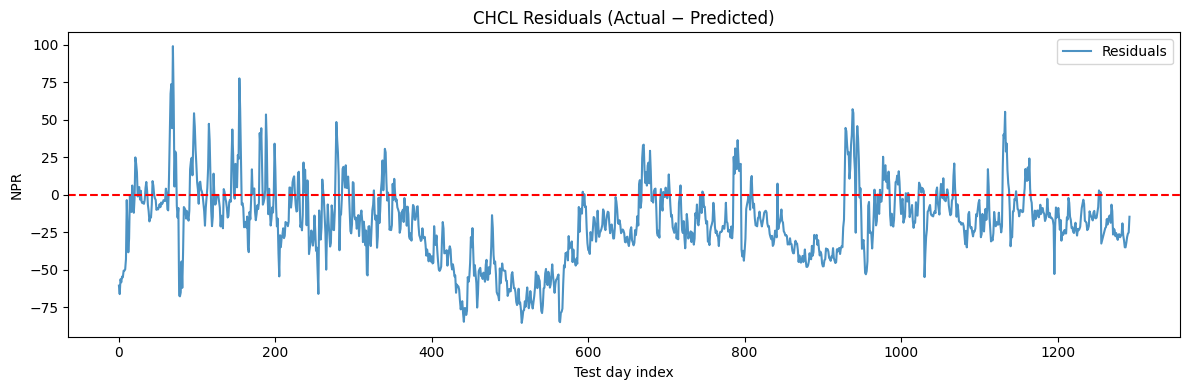

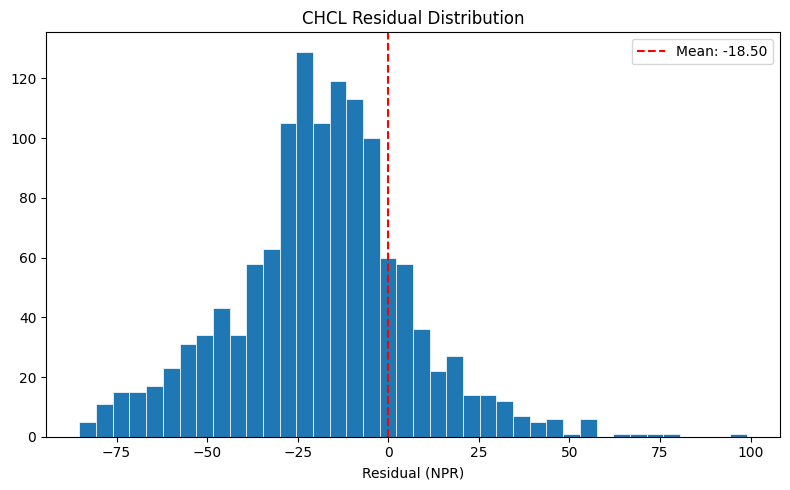

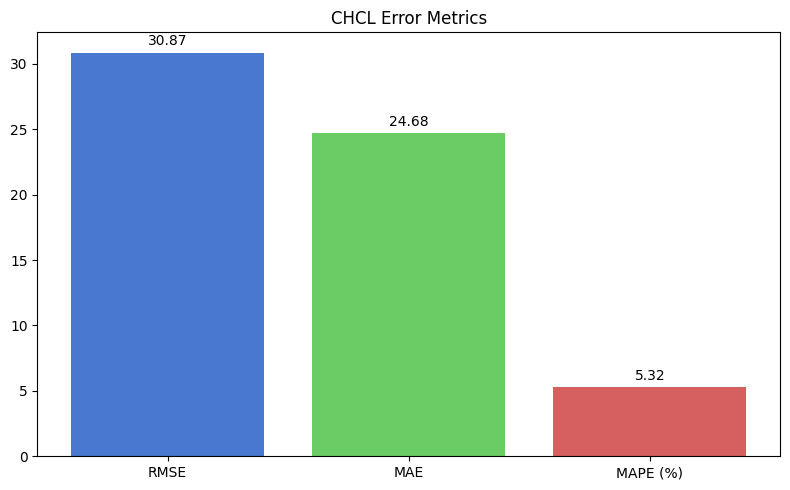

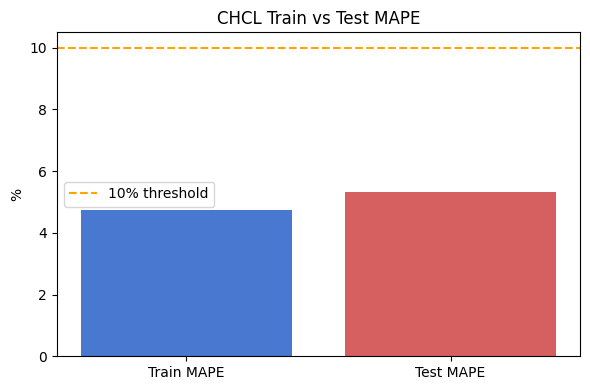

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Current Price  CHCL: 479.90
Tomorrow Price CHCL: 496.11  (UP 3.38%)
Latest date: 2026-03-03
Backend error: HTTPConnectionPool(host='192.168.254.13', port=80): Max retries exceeded with url: /predicted_price (Caused by ConnectTimeoutError(<HTTPConnection(host='192.168.254.13', port=80) at 0x794fbc7de060>, 'Connection to 192.168.254.13 timed out. (connect timeout=5)'))

All metrics saved → ../STOCK-EVALUATION-DATA-FIGURE/all_metrics_summary.csv
Symbol    RMSE    MAE     R2   MAPE  Train_MAPE  MAPE_gap  Epochs_run  Best_val_loss
  CHCL 30.8654 24.678 0.8496 5.3209      4.7336    0.5873          42       0.000091


In [13]:
import json
import requests
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential, Model
from keras.layers import (Dense, LSTM, Dropout, Bidirectional,
                          Input, Multiply, Permute, Flatten,
                          RepeatVector, Lambda, Activation)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras.backend as K

# ================= REPRODUCIBILITY =================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS  = 100
EPOCHS      = 150      # higher ceiling — EarlyStopping will cut it
PATIENCE    = 25       # was 15 → too aggressive; val loss plateaued at epoch 3-4 for NABIL
BATCH_SIZE  = 32
N_FEATURES  = 3        # Close + pct_change + Decayed_Sentiment (was 2 → root cause of flatline)

# ================= STOCK SELECTION =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]

stock_ignored = [
    "CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO",
    "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"
]
needCompareModel = ["CHCL"]  # extend as needed

all_metrics = []

for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD & FEATURE ENGINEERING =================
    df_raw = pd.read_csv(stock_path)

    # Reverse to chronological order (oldest first)
    df = df_raw[['Close', 'Decayed_Sentiment']].dropna().iloc[::-1].reset_index(drop=True)

    # --- FIX: Add pct_change feature ---
    # Root cause of NABIL flatline: model only saw raw price.
    # When test prices drifted to a range unseen in training, model had no signal.
    # pct_change() is scale-invariant — it works regardless of the price level.
    df['pct_change'] = df['Close'].pct_change()
    df = df.dropna().reset_index(drop=True)  # drop the first NaN row from pct_change

    print(f"Total rows after feature engineering: {len(df)}")
    print(df[['Close', 'pct_change', 'Decayed_Sentiment']].describe())

    # ================= FIG DIR =================
    FIG_DIR = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)

    # ================= VISUALISATION =================
    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.title(f"{symbol} Close Price with Moving Averages")
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_price_ma.png"))
    plt.show()

    # ================= CHRONOLOGICAL SPLIT (70 / 10 / 20) =================
    # Column order matters for the scaler: [Close, pct_change, Decayed_Sentiment]
    feature_cols = ['Close', 'pct_change', 'Decayed_Sentiment']
    data = df[feature_cols]

    n = len(data)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.80)

    data_train = data.iloc[:train_end]
    data_val   = data.iloc[train_end:val_end]
    data_test  = data.iloc[val_end:]

    print(f"Train: {len(data_train)}  Val: {len(data_val)}  Test: {len(data_test)}")
    print(f"Train Close range: {data_train.Close.min():.1f} – {data_train.Close.max():.1f}")
    print(f"Val   Close range: {data_val.Close.min():.1f}   – {data_val.Close.max():.1f}")
    print(f"Test  Close range: {data_test.Close.min():.1f}  – {data_test.Close.max():.1f}")

    # ================= SCALING — FIT ON TRAIN ONLY =================
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(data_train)

    # Build val input: last TIME_STEPS of train + val (for context window)
    val_context = pd.concat([data_train.tail(TIME_STEPS), data_val], ignore_index=True)
    val_scaled  = scaler.transform(val_context)

    # ================= SEQUENCE BUILDER =================
    def make_sequences(scaled_array, time_steps):
        X, y = [], []
        for i in range(time_steps, len(scaled_array)):
            X.append(scaled_array[i - time_steps:i])  # (TIME_STEPS, N_FEATURES)
            y.append(scaled_array[i, 0])               # predict scaled Close
        return np.array(X), np.array(y)

    x_train, y_train = make_sequences(train_scaled, TIME_STEPS)
    x_val,   y_val   = make_sequences(val_scaled,   TIME_STEPS)

    print(f"x_train: {x_train.shape}  x_val: {x_val.shape}")

    # ================= MODEL (with optional Bidirectional) =================
    # --- FIX: Bidirectional LSTM on first layer ---
    # A Bidirectional layer reads the sequence forwards AND backwards, giving
    # the model better context about each timestep. This is especially useful
    # for capturing momentum patterns (rising vs falling price phases).
    # Note: for real-time forecasting this is valid — we're looking at PAST
    # 100 days to predict day 101, so "future" within the window is still past data.
    def build_model(time_steps, n_features):
        model = Sequential([
            # Bidirectional on first layer captures both rising & falling momentum
            Bidirectional(
                LSTM(64, activation='tanh', return_sequences=True),
                input_shape=(time_steps, n_features)
            ),
            Dropout(0.2),

            LSTM(64, activation='tanh', return_sequences=True),
            Dropout(0.3),

            LSTM(32, activation='tanh', return_sequences=False),
            Dropout(0.3),

            Dense(16, activation='relu'),
            Dense(1),
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        return model

    model = build_model(TIME_STEPS, N_FEATURES)
    model.summary()

    # ================= CALLBACKS =================
    # --- FIX: min_delta added ---
    # Without min_delta, EarlyStopping counts epochs where val_loss improves
    # by even 0.000001. This caused NABIL's best epoch = 4 (trivial improvement).
    # min_delta=0.0001 requires a meaningful improvement to reset the counter.
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            min_delta=0.0001,           # <-- new: must improve meaningfully
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
    ]

    # ================= TRAINING =================
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=1,
    )

    epochs_run = len(history.history['loss'])
    best_val   = min(history.history['val_loss'])
    print(f"Stopped at epoch {epochs_run}  |  Best val_loss: {best_val:.6f}")

    # ================= SAVE MODEL =================
    MODEL_DIR  = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    # Use .keras format (avoids the HDF5 deprecation warning)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.keras")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    pre_test_context = data.iloc[train_end - TIME_STEPS: val_end]
    test_input_df    = pd.concat([pre_test_context, data_test], ignore_index=True)
    test_scaled      = scaler.transform(test_input_df)

    x_test, y_test = make_sequences(test_scaled, TIME_STEPS)
    print(f"x_test: {x_test.shape}")

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE TRANSFORM =================
    # The scaler has N_FEATURES columns. We only predicted column 0 (Close).
    # Fill the rest with zeros (they cancel out in inverse_transform for col 0).
    def inverse_close(arr_1d):
        dummy = np.zeros((len(arr_1d), N_FEATURES))
        dummy[:, 0] = arr_1d
        return scaler.inverse_transform(dummy)[:, 0]

    y_pred_inv = inverse_close(y_pred[:, 0])
    y_test_inv = inverse_close(y_test)

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_inv, y_pred_inv)
    r2   = r2_score(y_test_inv, y_pred_inv)
    mask = y_test_inv != 0
    mape = np.mean(np.abs((y_test_inv[mask] - y_pred_inv[mask]) / y_test_inv[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")

    # ================= OVERFITTING DIAGNOSIS =================
    train_pred     = model.predict(x_train)
    train_pred_inv = inverse_close(train_pred[:, 0])
    train_true_inv = inverse_close(y_train)
    train_mape     = np.mean(np.abs((train_true_inv - train_pred_inv) / train_true_inv)) * 100
    mape_gap       = mape - train_mape

    print(f"\nTrain MAPE: {train_mape:.4f}%  |  Test MAPE: {mape:.4f}%  |  Gap: {mape_gap:.4f}%")
    if train_mape < 2.0 and mape > 15:
        print("WARNING: Severe overfitting — consider more dropout or larger val set")
    elif mape_gap > 10:
        print("WARNING: Moderate overfit / distribution shift detected")
    else:
        print("OK: Train/Test MAPE gap is acceptable")

    # ================= PLOTS =================

    # Plot A: Loss curve (correctly named — NOT overwriting actual_vs_pred)
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_loss_curve.png"))
    plt.show()

    # Plot B: Actual vs Predicted
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_inv,  label='Actual',    linewidth=1.2)
    plt.plot(y_pred_inv,  label='Predicted', linewidth=1.2, alpha=0.85)
    plt.title(f"{symbol} Actual vs Predicted (Test Set)  —  MAPE: {mape:.2f}%  R²: {r2:.4f}")
    plt.xlabel('Test day index')
    plt.ylabel('Close Price (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # Plot C: Residuals over time
    residuals = y_test_inv - y_pred_inv
    plt.figure(figsize=(12, 4))
    plt.plot(residuals, alpha=0.8, label='Residuals')
    plt.axhline(0, linestyle='--', color='red')
    plt.title(f"{symbol} Residuals (Actual − Predicted)")
    plt.xlabel('Test day index')
    plt.ylabel('NPR')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot D: Residual distribution
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=40, edgecolor='white', linewidth=0.5)
    plt.axvline(0, linestyle='--', color='red', label=f'Mean: {residuals.mean():.2f}')
    plt.title(f"{symbol} Residual Distribution")
    plt.xlabel('Residual (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()

    # Plot E: Metrics bar
    plt.figure(figsize=(8, 5))
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}
    bars = plt.bar(metrics_plot.keys(), metrics_plot.values(),
                   color=['#4878CF', '#6ACC65', '#D65F5F'])
    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    plt.title(f"{symbol} Error Metrics")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()


    # ================= SAVE METRICS =================
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    all_metrics.append({
        "Symbol":        symbol,
        "RMSE":          round(rmse, 4),
        "MAE":           round(mae, 4),
        "R2":            round(r2, 4),
        "MAPE":          round(mape, 4),
        "Train_MAPE":    round(train_mape, 4),
        "MAPE_gap":      round(mape_gap, 4),
        "Epochs_run":    epochs_run,
        "Best_val_loss": round(best_val, 6),
    })
    pd.DataFrame(all_metrics).to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW'S PRICE PREDICTION =================
    last_100   = data[feature_cols].tail(TIME_STEPS)
    last_scaled = scaler.transform(last_100)
    X_input     = last_scaled[np.newaxis]        # shape (1, 100, 3)

    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy        = np.zeros((1, N_FEATURES))
    dummy[0, 0]  = tomorrow_scaled[0, 0]
    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    current_price = data['Close'].iloc[-1]
    change_pct    = ((tomorrow_price - current_price) / current_price) * 100
    direction     = "UP" if tomorrow_price > current_price else "DOWN"

    print(f"\nCurrent Price  {symbol}: {current_price:.2f}")
    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}  ({direction} {abs(change_pct):.2f}%)")

    df_date    = pd.read_csv(stock_path)[['Date_Stock']].dropna()
    latest_date = df_date.iloc[0]['Date_Stock']
    print(f"Latest date: {latest_date}")

    try:
        requests.post(
            'http://192.168.254.13/predicted_price',
            json={
                "predicted_price": float(tomorrow_price),
                "stock":           symbol,
                "date":            latest_date,
                "current_price":   float(current_price),
                "direction":       direction,
                "change_pct":      float(change_pct),
            },
            timeout=5,
        )
        print("Sent to backend.")
    except Exception as e:
        print(f"Backend error: {e}")

# ================= GLOBAL SUMMARY =================
if all_metrics:
    summary_path = "../STOCK-EVALUATION-DATA-FIGURE/all_metrics_summary.csv"
    pd.DataFrame(all_metrics).to_csv(summary_path, index=False)
    print(f"\nAll metrics saved → {summary_path}")
    print(pd.DataFrame(all_metrics).to_string(index=False))


===== Processing BARUN =====
Total rows after feature engineering: 2280
             Close   pct_change  Decayed_Sentiment
count  2280.000000  2280.000000        2280.000000
mean    284.673855     0.000593           0.039424
std     138.576005     0.032137           0.165044
min      76.000000    -0.335830          -0.891733
25%     192.000000    -0.017214           0.000000
50%     258.900000    -0.000383           0.000000
75%     389.542500     0.014493           0.000000
max     750.000000     0.100000           1.313269


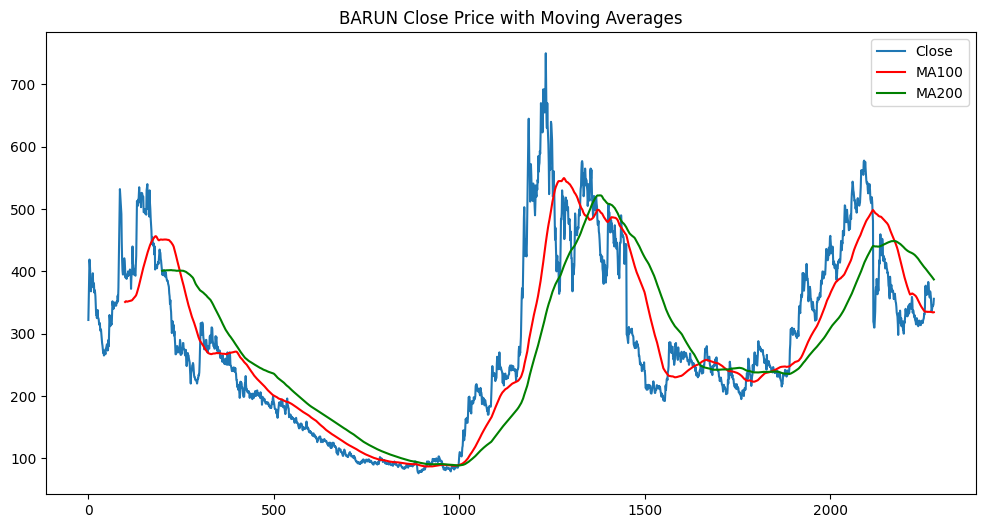

Train: 1596  Val: 228  Test: 456
Train Close range: 76.0 – 750.0
Val   Close range: 195.0   – 288.0
Test  Close range: 215.3  – 577.8
x_train: (1496, 100, 3)  x_val: (228, 100, 3)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_5 (Bidirectional) │ (None, 100, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_64 (LSTM)                  │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_65 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,185 (379.63 KB)

 Trainable params: 97,185 (379.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - loss: 0.0192 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - loss: 0.0051 - val_loss: 3.8951e-04 - learning_rate: 0.0010
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0041 - val_loss: 3.1142e-04 - learning_rate: 0.0010
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0037 - val_loss: 3.9860e-04 - learning_rate: 0.0010
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0035 - val_loss: 2.6351e-04 - learning_rate: 0.0010
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0030 - val_loss: 4.2224e-04 - learning_rate: 0.0010
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0026 - val_loss: 2.3962e-04 - learning_rate: 0.0010
Epoch 8/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0025 - val_loss: 3.0975e-04 - learning_rate: 0.0010
Epoch 9/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0021 - val_loss: 6.8996e-0

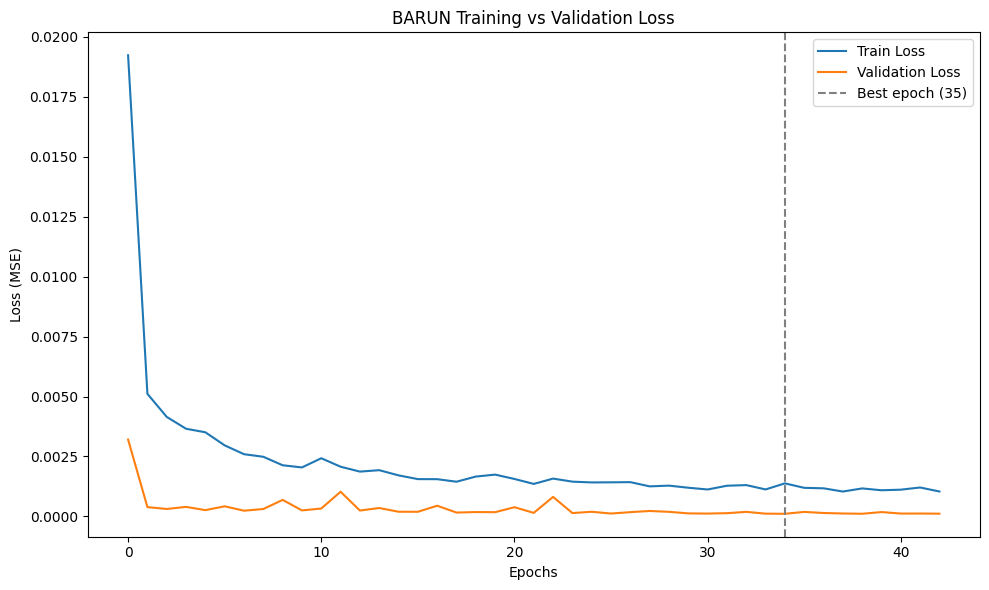

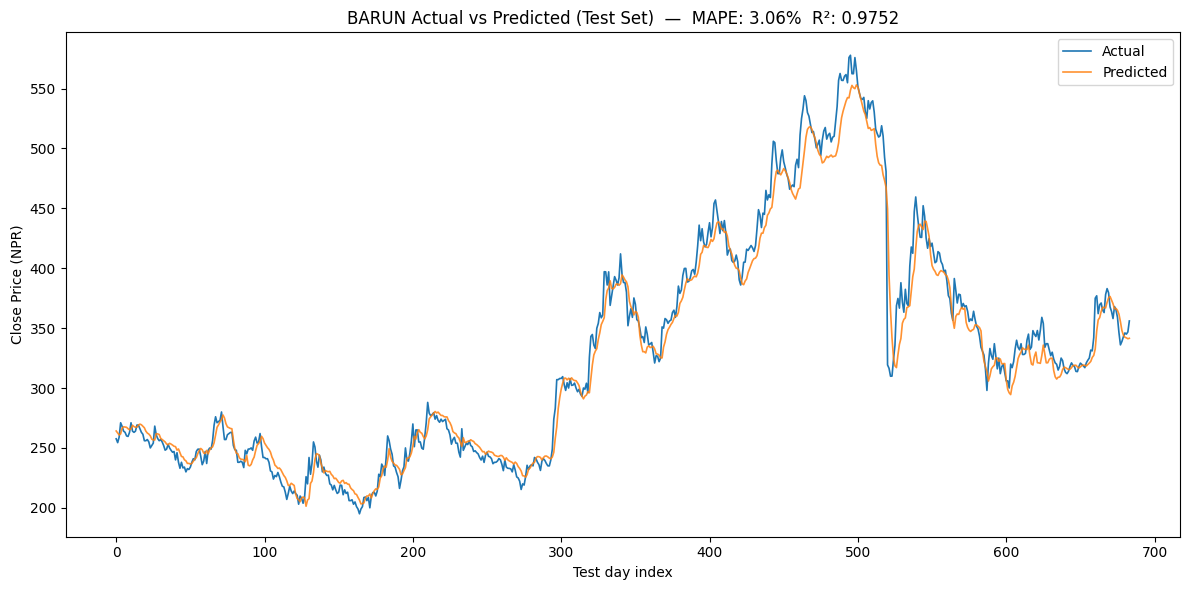

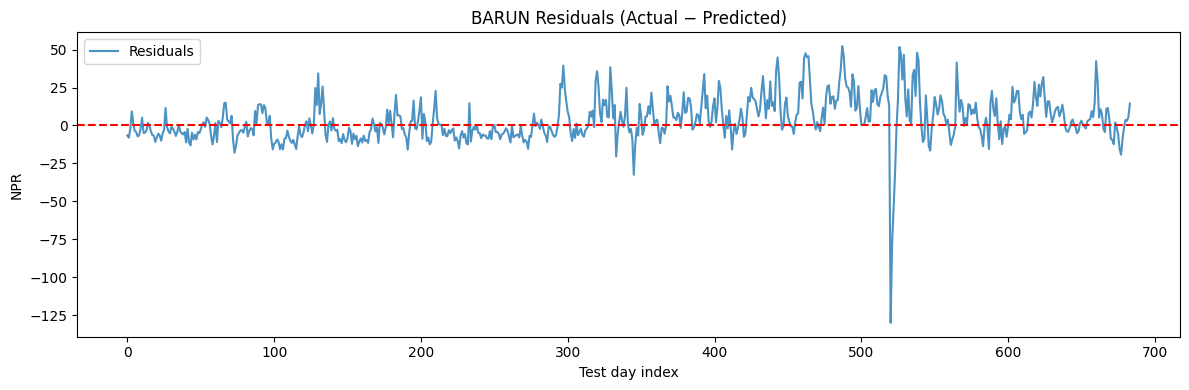

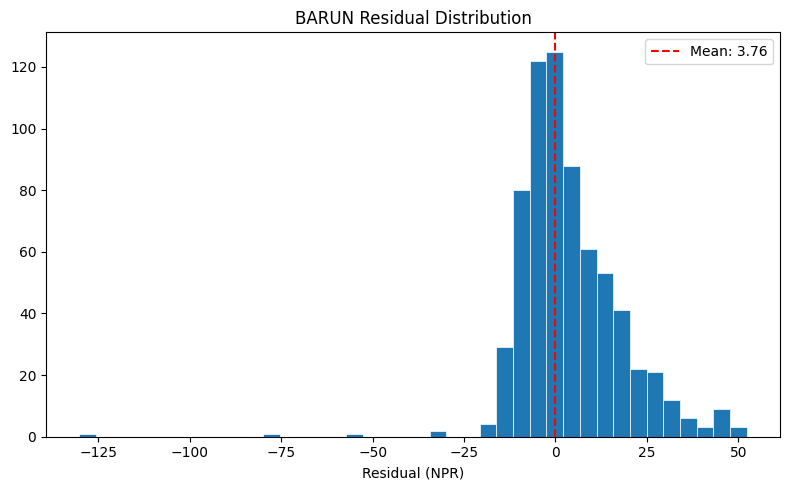

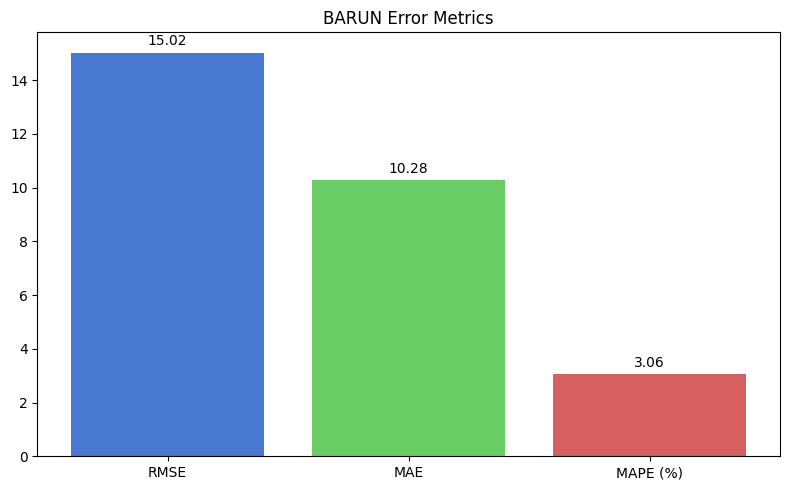

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Current Price  BARUN: 356.00
Tomorrow Price BARUN: 345.09
Latest date: 2026-03-03
Backend error: HTTPConnectionPool(host='192.168.254.13', port=80): Max retries exceeded with url: /predicted_price (Caused by ConnectTimeoutError(<HTTPConnection(host='192.168.254.13', port=80) at 0x794f836a2de0>, 'Connection to 192.168.254.13 timed out. (connect timeout=5)'))

All metrics saved → ../STOCK-EVALUATION-DATA-FIGURE/all_metrics_summary.csv
Symbol    RMSE     MAE     R2   MAPE  Train_MAPE  MAPE_gap  Epochs_run  Best_val_loss
 BARUN 15.0229 10.2824 0.9752 3.0642      4.9502   -1.8859          43        0.00011


In [18]:
import json
import requests
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential, Model
from keras.layers import (Dense, LSTM, Dropout, Bidirectional,
                          Input, Multiply, Permute, Flatten,
                          RepeatVector, Lambda, Activation)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras.backend as K

# ================= REPRODUCIBILITY =================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS  = 100
EPOCHS      = 150      # higher ceiling — EarlyStopping will cut it
PATIENCE    = 25       # was 15 → too aggressive; val loss plateaued at epoch 3-4 for NABIL
BATCH_SIZE  = 32
N_FEATURES  = 3        # Close + pct_change + Decayed_Sentiment (was 2 → root cause of flatline)

# ================= STOCK SELECTION =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]

stock_ignored = [
    "CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO",
    "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"
]
needCompareModel = ["BARUN"]  # extend as needed

all_metrics = []

for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD & FEATURE ENGINEERING =================
    df_raw = pd.read_csv(stock_path)

    # Reverse to chronological order (oldest first)
    df = df_raw[['Close', 'Decayed_Sentiment']].dropna().iloc[::-1].reset_index(drop=True)

    # --- FIX: Add pct_change feature ---
    # Root cause of NABIL flatline: model only saw raw price.
    # When test prices drifted to a range unseen in training, model had no signal.
    # pct_change() is scale-invariant — it works regardless of the price level.
    df['pct_change'] = df['Close'].pct_change()
    df = df.dropna().reset_index(drop=True)  # drop the first NaN row from pct_change

    print(f"Total rows after feature engineering: {len(df)}")
    print(df[['Close', 'pct_change', 'Decayed_Sentiment']].describe())

    # ================= FIG DIR =================
    FIG_DIR = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)

    # ================= VISUALISATION =================
    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12, 6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.title(f"{symbol} Close Price with Moving Averages")
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_price_ma.png"))
    plt.show()

    # ================= CHRONOLOGICAL SPLIT (70 / 10 / 20) =================
    # Column order matters for the scaler: [Close, pct_change, Decayed_Sentiment]
    feature_cols = ['Close', 'pct_change', 'Decayed_Sentiment']
    data = df[feature_cols]

    n = len(data)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.80)

    data_train = data.iloc[:train_end]
    data_val   = data.iloc[train_end:val_end]
    data_test  = data.iloc[val_end:]

    print(f"Train: {len(data_train)}  Val: {len(data_val)}  Test: {len(data_test)}")
    print(f"Train Close range: {data_train.Close.min():.1f} – {data_train.Close.max():.1f}")
    print(f"Val   Close range: {data_val.Close.min():.1f}   – {data_val.Close.max():.1f}")
    print(f"Test  Close range: {data_test.Close.min():.1f}  – {data_test.Close.max():.1f}")

    # ================= SCALING — FIT ON TRAIN ONLY =================
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(data_train)

    # Build val input: last TIME_STEPS of train + val (for context window)
    val_context = pd.concat([data_train.tail(TIME_STEPS), data_val], ignore_index=True)
    val_scaled  = scaler.transform(val_context)

    # ================= SEQUENCE BUILDER =================
    def make_sequences(scaled_array, time_steps):
        X, y = [], []
        for i in range(time_steps, len(scaled_array)):
            X.append(scaled_array[i - time_steps:i])  # (TIME_STEPS, N_FEATURES)
            y.append(scaled_array[i, 0])               # predict scaled Close
        return np.array(X), np.array(y)

    x_train, y_train = make_sequences(train_scaled, TIME_STEPS)
    x_val,   y_val   = make_sequences(val_scaled,   TIME_STEPS)

    print(f"x_train: {x_train.shape}  x_val: {x_val.shape}")

    # ================= MODEL (with optional Bidirectional) =================
    # --- FIX: Bidirectional LSTM on first layer ---
    # A Bidirectional layer reads the sequence forwards AND backwards, giving
    # the model better context about each timestep. This is especially useful
    # for capturing momentum patterns (rising vs falling price phases).
    # Note: for real-time forecasting this is valid — we're looking at PAST
    # 100 days to predict day 101, so "future" within the window is still past data.
    def build_model(time_steps, n_features):
        model = Sequential([
            # Bidirectional on first layer captures both rising & falling momentum
            Bidirectional(
                LSTM(64, activation='tanh', return_sequences=True),
                input_shape=(time_steps, n_features)
            ),
            Dropout(0.2),

            LSTM(64, activation='tanh', return_sequences=True),
            Dropout(0.3),

            LSTM(32, activation='tanh', return_sequences=False),
            Dropout(0.3),

            Dense(16, activation='relu'),
            Dense(1),
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        return model

    model = build_model(TIME_STEPS, N_FEATURES)
    model.summary()

    # ================= CALLBACKS =================
    # --- FIX: min_delta added ---
    # Without min_delta, EarlyStopping counts epochs where val_loss improves
    # by even 0.000001. This caused NABIL's best epoch = 4 (trivial improvement).
    # min_delta=0.0001 requires a meaningful improvement to reset the counter.
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            min_delta=0.0001,           # <-- new: must improve meaningfully
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
    ]

    # ================= TRAINING =================
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        callbacks=callbacks,
        verbose=1,
    )

    epochs_run = len(history.history['loss'])
    best_val   = min(history.history['val_loss'])
    print(f"Stopped at epoch {epochs_run}  |  Best val_loss: {best_val:.6f}")

    # ================= SAVE MODEL =================
    MODEL_DIR  = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    # Use .keras format (avoids the HDF5 deprecation warning)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.keras")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    pre_test_context = data.iloc[train_end - TIME_STEPS: val_end]
    test_input_df    = pd.concat([pre_test_context, data_test], ignore_index=True)
    test_scaled      = scaler.transform(test_input_df)

    x_test, y_test = make_sequences(test_scaled, TIME_STEPS)
    print(f"x_test: {x_test.shape}")

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE TRANSFORM =================
    # The scaler has N_FEATURES columns. We only predicted column 0 (Close).
    # Fill the rest with zeros (they cancel out in inverse_transform for col 0).
    def inverse_close(arr_1d):
        dummy = np.zeros((len(arr_1d), N_FEATURES))
        dummy[:, 0] = arr_1d
        return scaler.inverse_transform(dummy)[:, 0]

    y_pred_inv = inverse_close(y_pred[:, 0])
    y_test_inv = inverse_close(y_test)

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_inv, y_pred_inv)
    r2   = r2_score(y_test_inv, y_pred_inv)
    mask = y_test_inv != 0
    mape = np.mean(np.abs((y_test_inv[mask] - y_pred_inv[mask]) / y_test_inv[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")

    # ================= OVERFITTING DIAGNOSIS =================
    train_pred     = model.predict(x_train)
    train_pred_inv = inverse_close(train_pred[:, 0])
    train_true_inv = inverse_close(y_train)
    train_mape     = np.mean(np.abs((train_true_inv - train_pred_inv) / train_true_inv)) * 100
    mape_gap       = mape - train_mape

    print(f"\nTrain MAPE: {train_mape:.4f}%  |  Test MAPE: {mape:.4f}%  |  Gap: {mape_gap:.4f}%")
    if train_mape < 2.0 and mape > 15:
        print("WARNING: Severe overfitting — consider more dropout or larger val set")
    elif mape_gap > 10:
        print("WARNING: Moderate overfit / distribution shift detected")
    else:
        print("OK: Train/Test MAPE gap is acceptable")

    # ================= PLOTS =================

    # Plot A: Loss curve (correctly named — NOT overwriting actual_vs_pred)
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch+1})')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_loss_curve.png"))
    plt.show()

    # Plot B: Actual vs Predicted
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_inv,  label='Actual',    linewidth=1.2)
    plt.plot(y_pred_inv,  label='Predicted', linewidth=1.2, alpha=0.85)
    plt.title(f"{symbol} Actual vs Predicted (Test Set)  —  MAPE: {mape:.2f}%  R²: {r2:.4f}")
    plt.xlabel('Test day index')
    plt.ylabel('Close Price (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # Plot C: Residuals over time
    residuals = y_test_inv - y_pred_inv
    plt.figure(figsize=(12, 4))
    plt.plot(residuals, alpha=0.8, label='Residuals')
    plt.axhline(0, linestyle='--', color='red')
    plt.title(f"{symbol} Residuals (Actual − Predicted)")
    plt.xlabel('Test day index')
    plt.ylabel('NPR')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot D: Residual distribution
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=40, edgecolor='white', linewidth=0.5)
    plt.axvline(0, linestyle='--', color='red', label=f'Mean: {residuals.mean():.2f}')
    plt.title(f"{symbol} Residual Distribution")
    plt.xlabel('Residual (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()

    # Plot E: Metrics bar
    plt.figure(figsize=(8, 5))
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}
    bars = plt.bar(metrics_plot.keys(), metrics_plot.values(),
                   color=['#4878CF', '#6ACC65', '#D65F5F'])
    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    plt.title(f"{symbol} Error Metrics")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()


    # ================= SAVE METRICS =================
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    all_metrics.append({
        "Symbol":        symbol,
        "RMSE":          round(rmse, 4),
        "MAE":           round(mae, 4),
        "R2":            round(r2, 4),
        "MAPE":          round(mape, 4),
        "Train_MAPE":    round(train_mape, 4),
        "MAPE_gap":      round(mape_gap, 4),
        "Epochs_run":    epochs_run,
        "Best_val_loss": round(best_val, 6),
    })
    pd.DataFrame(all_metrics).to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW'S PRICE PREDICTION =================
    last_100   = data[feature_cols].tail(TIME_STEPS)
    last_scaled = scaler.transform(last_100)
    X_input     = last_scaled[np.newaxis]        # shape (1, 100, 3)

    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy        = np.zeros((1, N_FEATURES))
    dummy[0, 0]  = tomorrow_scaled[0, 0]
    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    current_price = data['Close'].iloc[-1]
    change_pct    = ((tomorrow_price - current_price) / current_price) * 100
    direction     = "UP" if tomorrow_price > current_price else "DOWN"

    print(f"\nCurrent Price  {symbol}: {current_price:.2f}")
    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    df_date    = pd.read_csv(stock_path)[['Date_Stock']].dropna()
    latest_date = df_date.iloc[0]['Date_Stock']
    print(f"Latest date: {latest_date}")

    try:
        requests.post(
            'http://192.168.254.13/predicted_price',
            json={
                "predicted_price": float(tomorrow_price),
                "stock":           symbol,
                "date":            latest_date,
                "current_price":   float(current_price),
                "direction":       direction,
                "change_pct":      float(change_pct),
            },
            timeout=5,
        )
        print("Sent to backend.")
    except Exception as e:
        print(f"Backend error: {e}")

# ================= GLOBAL SUMMARY =================
if all_metrics:
    summary_path = "../STOCK-EVALUATION-DATA-FIGURE/all_metrics_summary.csv"
    pd.DataFrame(all_metrics).to_csv(summary_path, index=False)
    print(f"\nAll metrics saved → {summary_path}")
    print(pd.DataFrame(all_metrics).to_string(index=False))